In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score,auc,roc_auc_score,roc_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputClassifier

In [3]:
train_info = pd.read_csv("train_info.csv")
test_info = pd.read_csv("test_info.csv")
test_answer = pd.read_csv("test_answer.csv")

In [4]:
def chenge(x):
    return [int(i) for i in str(x).replace('[','').replace(']','').split() if i.strip() != '']

In [5]:
train_info['cut_point'] = train_info['cut_point'].apply(chenge)
test_info['cut_point'] = test_info['cut_point'].apply(chenge)

In [6]:
data_train = []
data_test = []

In [7]:
for idx, row in train_info.iterrows():
    unique_id = row['unique_id']
    cut_points = row['cut_point']
    mode = row['mode']
    file_path = f"train_data/{unique_id}.txt"

    sensor_df = pd.read_csv(file_path, header=None, sep=r'\s+', names=['Ax','Ay','Az','Gx','Gy','Gz'])
    sensor_df = sensor_df.apply(pd.to_numeric, errors='coerce').dropna()

    prev = 0
    for cp in cut_points:
        segment = sensor_df.iloc[prev:cp]
        prev = cp
        if len(segment) == 0:
            continue

        segment_mean = segment.mean()
        segment_std = segment.std()
        features = pd.concat([segment_mean, segment_std]).tolist()

        data_train.append({
            'unique_id': unique_id,
            'mode': mode,
            'play years': row['play years'],
            'hold racket handed': row['hold racket handed'],
            'level': row['level'],
            'gender': row['gender'],
            **{f'feat{i}': features[i] for i in range(len(features))}
        })


In [8]:
for idx, row in test_info.iterrows():
    unique_id2 = row['unique_id']
    cut_points2 = row['cut_point']
    mode2 = row['mode']
    file_path2 = f"test_data/{unique_id2}.txt"

    sensor_df2 = pd.read_csv(file_path2, header=None, sep=r'\s+', names=['Ax','Ay','Az','Gx','Gy','Gz'])
    sensor_df2 = sensor_df2.apply(pd.to_numeric, errors='coerce').dropna()

    prev2 = 0
    for cp2 in cut_points2:
        segment2 = sensor_df2.iloc[prev2:cp2]
        prev2 = cp2
        if len(segment2) == 0:
            continue

        segment_mean2 = segment2.mean()
        segment_std2 = segment2.std()
        features2 = pd.concat([segment_mean2, segment_std2]).tolist()

        data_test.append({
            'unique_id': unique_id2,
            'mode': mode2,
            **{f'feat{i}': features2[i] for i in range(len(features2))}
        })

In [9]:
final_df = pd.DataFrame(data_train)
final_df2 = pd.DataFrame(data_test)

In [24]:
X = final_df[[col for col in final_df.columns if col.startswith('feat')] + ['mode']].copy()
if X['mode'].dtype == 'object':
    X['mode'] = X['mode'].astype('category').cat.codes

In [25]:
y = final_df[['play years','hold racket handed','level','gender']].copy()
label_encoders = {}

In [26]:
for col in y.columns:
    if y[col].dtype == 'object':
        le = LabelEncoder()
        y[col] = le.fit_transform(y[col])
        label_encoders[col] = le

In [27]:
X2 = final_df2[[col for col in final_df2.columns if col.startswith('feat')] + ['mode']].copy()
if X2['mode'].dtype == 'object':
    X2['mode'] = X2['mode'].astype('category').cat.codes

In [28]:
clf = MultiOutputClassifier(DecisionTreeClassifier(max_depth=7, random_state=42))
clf.fit(X, y)
y_pred3 = clf.predict(X2)

In [29]:
pred_df = final_df2[['unique_id']].copy()
for i, col in enumerate(y.columns):
    pred_df[col] = y_pred3[:, i]

In [30]:
agg_pred = pred_df.groupby('unique_id').agg(lambda x: x.mode()[0]).reset_index()

In [31]:
merged = pd.merge(test_answer, agg_pred, on='unique_id', suffixes=('_true', '_pred'))

In [32]:
from sklearn import metrics

In [33]:
merged[f"{'hold racket handed'}_true"].values - 1

array([0, 0, 0, ..., 0, 0, 0])

In [34]:
 merged[f"{'hold racket handed'}_pred"].values - 1

array([0, 0, 0, ..., 0, 0, 0])

play years Accuracy: 0.43006993006993005
play years f1: 0.33723821758655714
hold racket handed Accuracy: 0.9923076923076923
hold racket handed f1: 0.9923578998580481
level Accuracy: 0.4643356643356643
level f1: 0.39043112119692186
gender Accuracy: 0.7923076923076923
gender f1: 0.7482517482517482


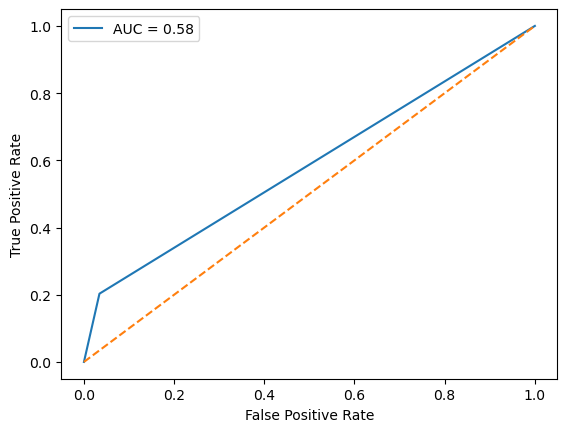

In [35]:
import matplotlib.pyplot as plt
for col in y.columns:
    print(f"{col} Accuracy:", accuracy_score(merged[f"{col}_true"], merged[f"{col}_pred"]))
    print(f"{col} f1:", f1_score(merged[f"{col}_true"], merged[f"{col}_pred"],average =  'weighted',labels = train_info[col].unique()))
fpr, tpr, _ = roc_curve(merged["gender_true"].values - 1,
                        merged["gender_pred"].values - 1)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()